# N&C VAT Campaign — consolidated results (2026-07-15/16, v4.2 corpus)

All numbers load live from artifact JSONs in `datasets/notice-and-comment/v4/`.
Canonical prose writeup: `datasets/notice-and-comment/README.md` §9. Memory:
`project_nc_vat_run.md`, `project_nc_agency_size_throughput.md`.

**Protocol invariants**: AUC everywhere (threshold-free); StratifiedGroupKFold grouped by
docket (rules never straddle folds); y's majority-vote collapsed per comment; Gemma-4-31B
judge for A with 3 blinded anchors in every scoring batch (anchor separation
.872/.523/.032 pre-GEPA, .911/.575/.057 post — never collapsed).

In [120]:
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

V4 = Path('../datasets/notice-and-comment/v4')
# validated default palette (dataviz reference instance, light mode)
PAL = dict(blue='#2a78d6', green='#008300', magenta='#e87ba4', yellow='#eda100',
           aqua='#1baf7a', orange='#eb6834', violet='#4a3aa7')
INK, INK2, SURF = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF,
                     'text.color': INK, 'axes.labelcolor': INK2,
                     'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.edgecolor': '#d8d7d2', 'axes.grid': True,
                     'grid.color': '#e8e7e2', 'grid.linewidth': 0.6,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10, 'figure.dpi': 110})

def J(name): 
    p = V4/name
    return json.loads(p.read_text()) if p.exists() else None

vat       = json.loads(Path('data/nc_vat.json').read_text())
yaudit    = J('nc_y_audit.json')
agree_pa  = J('nc_agree_per_agency.json')
merged    = J('nc_size_vat_merged.json')
divers    = J('nc_agency_docket_diversity.json')
responded = J('nc_responded_or_not.json')
hist      = json.loads((V4/'gepa_nc'/'history.json').read_text())
print('all artifacts loaded')

all artifacts loaded


## 1. Master instrument × y table

Three live y-variables (majority-vote collapsed, docket-grouped CV):
- **outcome** — agency changed the rule (MADE vs NONE). *Rule-level, not comment-level.*
- **agree** — agency accepted the comment's position (accepted/agree vs disagree).
- **responded** — comment was individually matched to any agency response vs never matched
  (≥700 chars both classes; matcher-recall caveat applies).

Retired by policy: **any-MADE** union y (n_labels-confounded, .695 mechanically).

In [121]:
rows = []
def add(y, inst, auc, ci=None, note=''):
    lo, hi = (ci or [None, None])
    rows.append(dict(y=y, instrument=inst, auc=auc, lo=lo, hi=hi, note=note))

po = vat['pooled_out']
add('outcome','char_len', po['nuisance']['char_len_auc'])
add('outcome','V regex(27)', po['V']['auc'], po['V']['ci'])
add('outcome','A rubrics(pre-GEPA)', po['A']['auc'], po['A']['ci'])
add('outcome','V+A', po['VA']['auc'], po['VA']['ci'])
add('outcome','V_deep(12 hybrids)', .615, note='beats regex-V and 8B')
add('outcome','dense TF-IDF', po['dense']['auc'], po['dense']['ci'])
add('outcome','Llama-8B LoRA', .602, note='docket-disjoint; leaky internal split .893 — never quote')
add('outcome','A post-GEPA', .578, [.564,.593], 'fidelity up, prediction down')

ya = yaudit['agree vs disagree']
add('agree','char_len', .522)
add('agree','stance-only baseline', .603)
add('agree','V regex(27)', ya['V']['auc'])
add('agree','A rubrics(pre-GEPA)', ya['A']['auc'])
add('agree','V+A', ya['VA']['auc'])
add('agree','V_deep(12)', .595, note='stance_alignment alone .627')
add('agree','dense TF-IDF', ya['dense']['auc'])
add('agree','Llama-8B LoRA', .647, note='docket-disjoint')
add('agree','A post-GEPA', .595, [.583,.610])

add('responded','char_len', responded['char_len_auc_ungrouped'], note='BELOW .5 — unmatched comments are longer')
add('responded','V regex(27)', responded['V_auc'], responded['V_ci'])
add('responded','A rubrics(pre-GEPA)', responded['A_auc'], responded['A_ci'])
add('responded','V+A', responded['VA_auc'], responded['VA_ci'])
add('responded','dense TF-IDF', responded['dense_auc'], responded['dense_ci'], 'campaign high; T-hat = dense - V+A = +.066')

master = pd.DataFrame(rows)
master.style.format({'auc':'{:.3f}','lo':'{:.3f}','hi':'{:.3f}'}, na_rep='')

,y,instrument,auc,lo,hi,note
0,outcome,char_len,0.595,,,
1,outcome,V regex(27),0.595,0.582,0.609,
2,outcome,A rubrics(pre-GEPA),0.592,0.579,0.607,
3,outcome,V+A,0.593,0.580,0.608,
4,outcome,V_deep(12 hybrids),0.615,,,beats regex-V and 8B
5,outcome,dense TF-IDF,0.588,0.576,0.601,
6,outcome,Llama-8B LoRA,0.602,,,docket-disjoint; leaky internal split .893 — never quote
7,outcome,A post-GEPA,0.578,0.564,0.593,"fidelity up, prediction down"
8,agree,char_len,0.522,,,
9,agree,stance-only baseline,0.603,,,


/Users/spangher/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


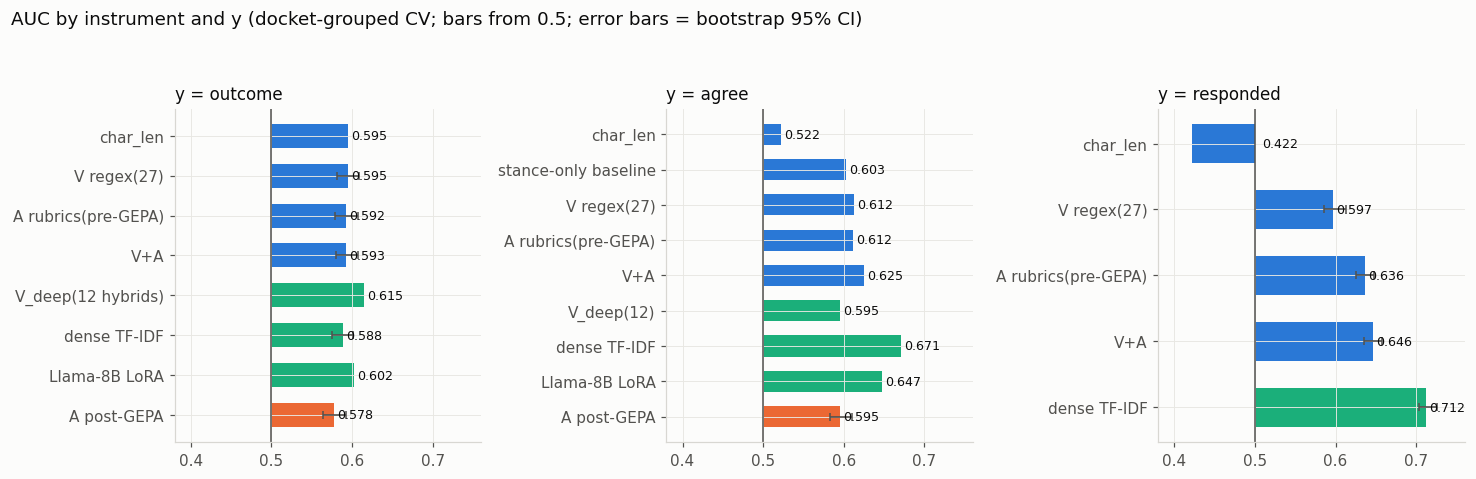

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True)
for ax, y in zip(axes, ['outcome','agree','responded']):
    sub = master[master.y==y].iloc[::-1]
    cols = [PAL['orange'] if 'post-GEPA' in i else PAL['aqua'] if ('deep' in i or '8B' in i or 'dense' in i)
            else PAL['blue'] for i in sub.instrument]
    ax.barh(sub.instrument, sub.auc-0.5, left=0.5, color=cols, height=0.6)
    err = sub.dropna(subset=['lo'])
    ax.errorbar(err.auc, err.instrument, xerr=[err.auc-err.lo, err.hi-err.auc],
                fmt='none', ecolor=INK2, elinewidth=1.1, capsize=2.5)
    for _, r in sub.iterrows():
        ax.text(max(r.auc, .505)+.004, r.instrument, f'{r.auc:.3f}', va='center', fontsize=8.3, color=INK)
    ax.axvline(0.5, color=INK2, lw=1)
    ax.set_title(f'y = {y}', fontsize=11, color=INK, loc='left')
    ax.set_xlim(0.38, 0.76)
fig.suptitle('AUC by instrument and y (docket-grouped CV; bars from 0.5; error bars = bootstrap 95% CI)',
             x=0.01, ha='left', fontsize=12, color=INK)
plt.tight_layout(rect=[0,0,1,0.93]); plt.show()
# blue = symbolic/judge instruments · aqua = learned/deep instruments · orange = post-GEPA (negative result)

## 2. Where the signal lives: within- vs between-docket

For each y, out-of-fold scores are compared **within** dockets (pure comment-level signal;
docket identity conditioned out) vs **between** docket means. Outcome-y is entirely
between-docket (.498 within = chance) → it measures which *rules* change. Agree-y is the only
y with genuine comment-level signal (.558 within).

In [123]:
ya_rows=[]
for name, d in yaudit.items():
    ya_rows.append(dict(y=name, V=d['V']['auc'], A=d['A']['auc'], VA=d['VA']['auc'], dense=d['dense']['auc'],
        within_VA=d['VA'].get('within'), within_dense=d['dense'].get('within'),
        between_VA=d['VA'].get('between'), between_dense=d['dense'].get('between')))
pd.DataFrame(ya_rows).set_index('y').style.format('{:.3f}', na_rep='')

,V,A,VA,dense,within_VA,within_dense,between_VA,between_dense
y,,,,,,,,
outcome_maj (baseline),0.595,0.592,0.593,0.588,0.498,0.524,0.652,0.682
outcome_maj|substantive,0.598,0.590,0.589,0.577,0.512,0.519,0.617,0.658
any_consider vs NONE,0.603,0.589,0.587,0.586,0.495,0.543,0.660,0.676
MADE vs CONSIDERED,0.568,0.496,0.498,0.591,0.482,0.525,0.510,0.546
engagement subst vs proc,0.528,0.557,0.560,0.583,0.529,0.561,0.604,0.635
agree vs disagree,0.612,0.612,0.625,0.671,0.558,0.558,0.626,0.654
agree+part vs disagree,0.606,0.594,0.606,0.628,0.495,0.496,0.617,0.625


## 2b. Time axis (docket year)

Pooled outcome-y AUC by docket-year bucket. No monotone trend — treat as descriptive only;
buckets differ in agency composition (a confound), so this is not a clean over-time story.

In [124]:
by = vat.get('by_year', {})
if by:
    tr = pd.DataFrame([dict(bucket=k, n=v['n'], V=v['V']['auc'], A=v['A']['auc'],
                            VA=v['VA']['auc'], dense=v['dense']['auc']) for k,v in by.items()])
    display(tr.set_index('bucket').style.format({'V':'{:.3f}','A':'{:.3f}','VA':'{:.3f}','dense':'{:.3f}'}))
else:
    print('no by_year block in nc_vat.json')

,n,V,A,VA,dense
bucket,,,,,
2014-2017,2158,0.596,0.547,0.531,0.582
2018-2020,2524,0.554,0.478,0.467,0.546
2021-2026,2142,0.584,0.585,0.591,0.597


## 3. GEPA: construct fidelity up, prediction down (negative result)

**Fidelity** = per-rubric agreement between Gemma (current rubric text) and a frozen Sonnet
reference scoring of 63 dev comments against the ORIGINAL construct:
`0.5·categorical agreement({1.0,0.5,0.0,NA}) + 0.5·max(Spearman,0)`. Label-free. (This is
judge-to-reference agreement — NOT the reconstruction/recovery metric, and NOT predictive AUC.)

4 Sonnet-proposer rounds: fidelity .485→.577, anchors sharpened, 98/140 rubrics improved
univariately — **yet every multivariate AUC dropped, and agree-y's within-docket signal
collapsed .558→.501.** Descriptive reading: fidelity-optimization pulled all rubrics toward
Sonnet's construct reading → more redundancy (NA .64→.69), less judge-idiosyncratic variance —
and that idiosyncratic variance was carrying real predictive signal. **Part of the A-bank's
predictive power was unarticulated judge-reading residue, not the constructs.**
Pre-GEPA bank stays canonical. Follow-up: run the same test on peer-review's A-bank.

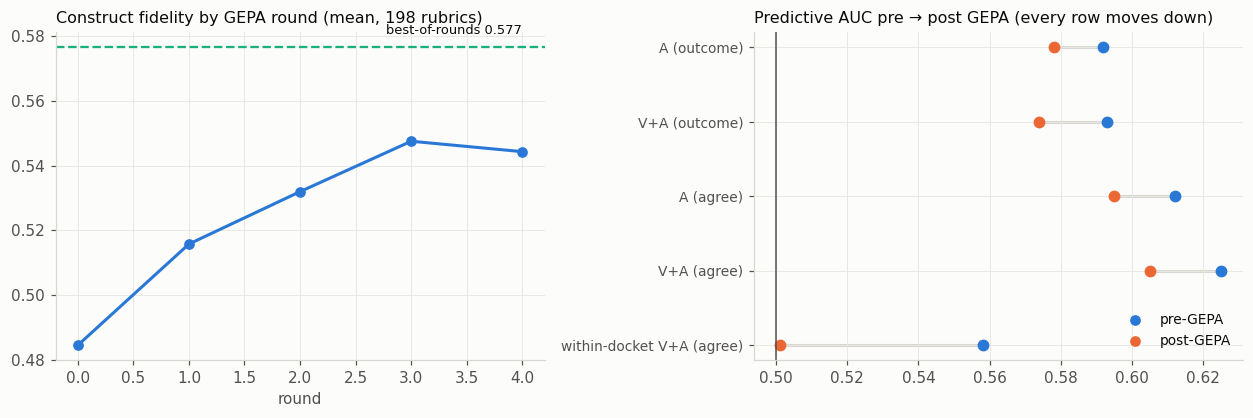

In [125]:
fid_rounds = {}
best = []
for rid, h in hist.items():
    for r, f in h['rounds'].items():
        fid_rounds.setdefault(int(r), []).append(f)
    best.append(h['best_fid'])
prog = {r: np.mean(v) for r, v in fid_rounds.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.9))
xs = sorted(prog)
ax1.plot(xs, [prog[x] for x in xs], color=PAL['blue'], lw=2, marker='o', ms=6)
ax1.axhline(np.mean(best), color=PAL['aqua'], lw=1.5, ls='--')
ax1.text(xs[-1], np.mean(best)+.004, f'best-of-rounds {np.mean(best):.3f}', ha='right', fontsize=8.5, color=INK)
ax1.set_title('Construct fidelity by GEPA round (mean, 198 rubrics)', loc='left', fontsize=10.5, color=INK)
ax1.set_xlabel('round')

pairs = [('A (outcome)', .592, .578), ('V+A (outcome)', .593, .574),
         ('A (agree)', .612, .595), ('V+A (agree)', .625, .605),
         ('within-docket V+A (agree)', .558, .501)]
yy = np.arange(len(pairs))[::-1]
for (nm, a, b), yv in zip(pairs, yy):
    ax2.plot([a, b], [yv, yv], color='#d8d7d2', lw=2, zorder=1)
    ax2.scatter([a], [yv], color=PAL['blue'], s=45, zorder=2)
    ax2.scatter([b], [yv], color=PAL['orange'], s=45, zorder=2)
ax2.set_yticks(yy); ax2.set_yticklabels([p[0] for p in pairs], fontsize=9)
ax2.axvline(.5, color=INK2, lw=1)
ax2.scatter([],[],color=PAL['blue'],label='pre-GEPA'); ax2.scatter([],[],color=PAL['orange'],label='post-GEPA')
ax2.legend(frameon=False, fontsize=9, loc='lower right')
ax2.set_title('Predictive AUC pre → post GEPA (every row moves down)', loc='left', fontsize=10.5, color=INK)
plt.tight_layout(); plt.show()

## 4. Deep-V: metric-seam hybrid programs (14 aspects, 3 waves)

`methods/metric_seam/hybrids/programs_notice_and_comment/` — LLM extracts typed fields,
deterministic program scores (0.65·code + 0.35·llm). Waves: **h0** comment-quality surface
(real CFR/USC citation grammar, redline detection, magnitude-aware CBA parsing…), **h1**
persuasion (graded stance, ask-modesty, deference, technical precision), **h2 verification
tier** — the program *decides correctness*: numeric arithmetic-consistency, and cited-authority
existence against a real eCFR index (49 titles / 9,700 parts, `cfr_parts_index.json.gz`).

**Headline: V_deep .615 ≥ Llama-8B .602 > V regex .595 (outcome-y)** — interpretable
programs match a fine-tuned dense model. Verification-tier univariates are modest
(authority_lookup .539, numeric_consistency .540) — existence/coherence checks are real
instruments but weakly discriminating at this y.

In [126]:
p3 = V4/'nc_deepv3_scores.npz'
dv = np.load(p3 if p3.exists() else V4/'nc_deepv2_scores.npz', allow_pickle=True)
names = [str(x) for x in dv['names']]
labs = json.loads((V4/'nc_vat_sample_labels_full.json').read_text())
AGREE={'accepted','agree'}; DIS={'disagree'}
def y_out(ls):
    oc=[l['outcome_collapsed'] for l in ls if l['outcome_collapsed'] in ('MADE','NONE')]
    p,n=oc.count('MADE'),oc.count('NONE'); return -1 if p==n else int(p>n)
def y_agr(ls):
    p=sum(l.get('response_type') in AGREE for l in ls); n=sum(l.get('response_type') in DIS for l in ls)
    return -1 if p==n else int(p>n)
from sklearn.metrics import roc_auc_score
ids=[str(i) for i in dv['doc_id']]; X=dv['X']
uni=[]
for yname,f in (('outcome',y_out),('agree',y_agr)):
    y=np.array([f(labs.get(i,[])) for i in ids]); v=y>=0
    for j,nm in enumerate(names):
        uni.append(dict(aspect=nm, y=yname, auc=roc_auc_score(y[v], X[v][:,j])))
uni=pd.DataFrame(uni).pivot(index='aspect', columns='y', values='auc')
uni.sort_values('outcome', ascending=False).style.format('{:.3f}')

y,agree,outcome
aspect,,
redline_ask,0.520,0.588
structure_org,0.537,0.587
technical_precision,0.535,0.579
evidence_provenance,0.522,0.567
ask_modesty,0.573,0.567
stake_specificity,0.545,0.566
stance_alignment,0.628,0.563
alternatives_analysis,0.513,0.557
citation_validity,0.519,0.548


## 5. Per-agency VAT (agree-y), sorted by dense

Reliability rule: <20 dockets in-sample → readout is docket-noise (FS's dense .269 confirmed
artifact: 6 dockets, .269–.421 across CV seeds). Sub-.35 tail values are noise, not anti-signal.

In [127]:
pa = pd.DataFrame(agree_pa).T.sort_values('dense', ascending=False)
dd = pd.DataFrame(divers).set_index('agency')
pa['n_dockets_sample'] = dd['n_dockets_sample']
pa['reliable'] = pa['n_dockets_sample'] >= 20
pa[['n','n_dockets_sample','reliable','dense','V','A','VA','Vdeep']].style.format(
    {'dense':'{:.3f}','V':'{:.3f}','A':'{:.3f}','VA':'{:.3f}','Vdeep':'{:.3f}'})

,n,n_dockets_sample,reliable,dense,V,A,VA,Vdeep
FAA,278.000000,180,True,0.773,0.702,0.586,0.595,0.723
DOT,159.000000,20,True,0.711,0.518,0.587,0.532,0.678
BLM,100.000000,7,False,0.666,0.558,0.315,0.361,0.408
FSIS,273.000000,16,False,0.638,0.514,0.611,0.612,0.507
USCBP,327.000000,13,False,0.633,0.568,0.400,0.451,0.632
IRS,95.000000,43,True,0.626,0.593,0.448,0.494,0.265
CDC,292.000000,18,False,0.619,0.631,0.621,0.625,0.706
AMS,302.000000,60,True,0.613,0.628,0.494,0.542,0.478
FDA,262.000000,89,True,0.601,0.610,0.522,0.580,0.601
EPA,285.000000,104,True,0.584,0.492,0.520,0.530,0.617


## 5b. Robustness: dropping the hardest-to-predict agencies

Does pruning the low-dense tail lift the pooled agree-y scores? **No — pooled AUC is
essentially invariant.** Pooled AUC is dominated by cross-agency comparison pairs, so removing
one agency's rows removes signal and noise proportionally; and most of the ugly per-agency
numbers (ICEB .191, FS .269) are docket-count noise, not a coherent "hard rows" population to
excise. No free lift from agency curation — the pooled row is robust to the tail.

In [128]:
drop = pd.DataFrame([
    dict(sample='all 21 agencies',              n=5046, V=.612, A=.612, VA=.625, Vdeep=.593, dense=.671),
    dict(sample='minus bottom-3 (ICEB,FS,NHTSA)',n=4218, V=.606, A=.613, VA=.620, Vdeep=.597, dense=.661),
    dict(sample='minus bottom-5 (+MSHA,USCIS)',  n=3838, V=.600, A=.608, VA=.615, Vdeep=.590, dense=.671),
])
drop.set_index('sample').style.format({'V':'{:.3f}','A':'{:.3f}','VA':'{:.3f}','Vdeep':'{:.3f}','dense':'{:.3f}'})

,n,V,A,VA,Vdeep,dense
sample,,,,,,
all 21 agencies,5046,0.612,0.612,0.625,0.593,0.671
"minus bottom-3 (ICEB,FS,NHTSA)",4218,0.606,0.613,0.620,0.597,0.661
"minus bottom-5 (+MSHA,USCIS)",3838,0.600,0.608,0.615,0.590,0.671


## 6. Collins RTK: agency size / throughput vs mechanizable signal

FTE headcount (FedScope Sept 2024) does **not** predict mechanizable signal (V_deep ρ=+.20 ns,
A ρ=−.03 ns). **Docket throughput does** (V_deep ρ=+.635, p=.003) — and it survives BOTH the
FAA-outlier exclusion (ρ=.571, p=.013) AND partialling out sample docket-diversity, the
mechanical grouped-CV reliability confound (ρ=.572, p=.013). The same two checks *killed* the
apparent dense and A correlations (dense → −.06). Refined hypothesis: rulemaking **case
throughput**, not organizational headcount, builds mechanically-legible comment-handling
structure. n=18–19; dockets are lifetime totals, not rates.

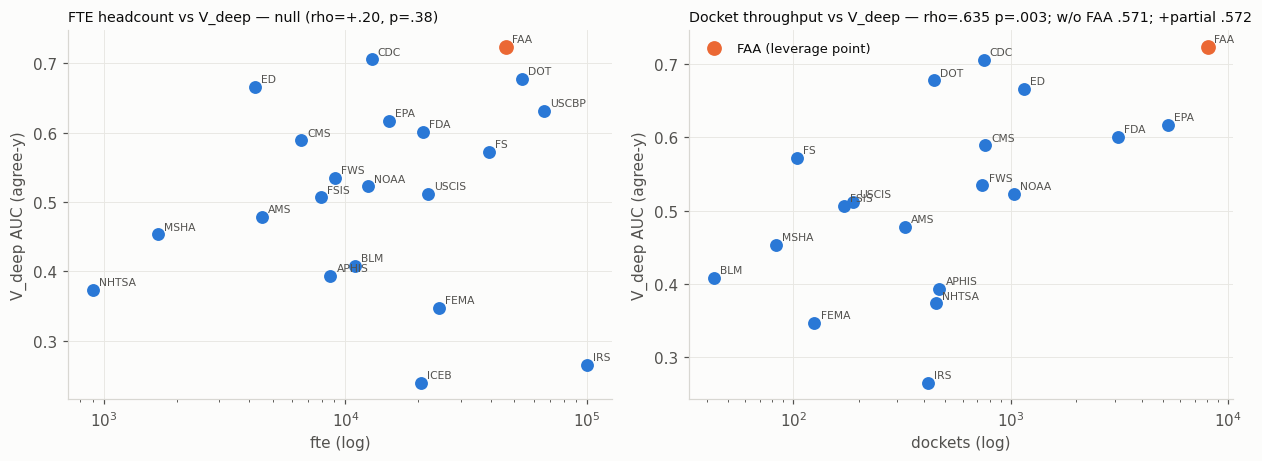

metric,A,V,Vdeep,dense
x,,,,
comments,0.342,0.116,0.399,0.061
dockets,0.507,0.023,0.635,0.242
fte,-0.025,0.496,0.204,0.325


In [129]:
mg = pd.DataFrame(merged)
mm = mg.merge(pd.DataFrame(divers)[['agency','n_dockets_sample']], on='agency', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
for ax, xcol, title in ((ax1,'fte','FTE headcount vs V_deep — null (rho=+.20, p=.38)'),
                        (ax2,'dockets','Docket throughput vs V_deep — rho=.635 p=.003; w/o FAA .571; +partial .572')):
    s = mm.dropna(subset=[xcol,'Vdeep'])
    faa = s.agency=='FAA'
    ax.scatter(s[~faa][xcol], s[~faa]['Vdeep'], s=55, color=PAL['blue'], zorder=2)
    ax.scatter(s[faa][xcol], s[faa]['Vdeep'], s=75, color=PAL['orange'], zorder=3, label='FAA (leverage point)')
    for _, r in s.iterrows():
        ax.annotate(r.agency, (r[xcol], r['Vdeep']), textcoords='offset points', xytext=(4,3), fontsize=7, color=INK2)
    ax.set_xscale('log'); ax.set_xlabel(xcol + ' (log)'); ax.set_ylabel('V_deep AUC (agree-y)')
    ax.set_title(title, loc='left', fontsize=9.3, color=INK)
ax2.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
tab=[]
for xk in ('fte','dockets','comments'):
    for yk in ('dense','Vdeep','A','V'):
        s=mm.dropna(subset=[xk,yk])
        rho,p=spearmanr(s[xk],s[yk])
        tab.append(dict(x=xk,metric=yk,rho=round(rho,3),p=round(p,3)))
pd.DataFrame(tab).pivot(index='x',columns='metric',values='rho')

## 7. Cross-domain: how this compares to code review (GitHub PRs)

The nearest code-review analog is `notes/2026-07-09__org-size-formalization.md` (244 org-owned
repos, DV = within-repo decision *consistency*: 5-fold within-repo AUC over the 82 VAT
features on y=rejected) plus `notes/2026-07-15__consul-collins-aside-status.md` (V-side).
Summary of the comparison:

| | N&C (agencies) | Code review (repos/orgs) |
|---|---|---|
| **org headcount vs signal** | FTE ⊥ V_deep/A (null) | org members ⊥ consistency (ρ=−.07, null) |
| **written formality** | — (not measured) | stars → CONTRIBUTING/formal files (ρ≈+.35) but **docs → consistency ρ=+0.00 — "docs don't bind"** |
| **small vs large** | — | **small orgs (≤5) MORE consistent** (.611 vs .566, p=.035) |
| **throughput vs signal** | **dockets → V_deep ρ=.635 (p=.003), survives 2 confound checks** | **NULL (run 2026-07-16, V-only DV)**: total_prs ρ=+.05, prs_per_day ρ=+.08, stars ρ=+.00 vs within-repo V-feature AUC, n=148 repos; robust to outlier-exclusion and n-PRs partial (`throughput_vs_within_auc.json`) |
| **V-side org effects** | — | null: "yield is a harness property, not an org property" |

Convergent story across both domains: **written/organizational formality artifacts and raw
headcount do not predict operative legibility.** The N&C result adds the positive half —
*case throughput* does — and that exact test is missing on the code side. The data to run it
is already staged: `outputs/org_vat/repo_metadata.tsv` (2,814 repos with stars / contributors
/ PR counts / age) + the staged per-repo A-AUC (GEPA+Gemma) infra from the consul-collins
thread. **That experiment has now been run (V-side)**: per-repo within-repo AUC reconstructed from
71,677 PR verdict records (V features only — the 64 A-metric channel from the 2026-07-09
analysis is unrecoverable), 148 repos with metadata. **Throughput does NOT predict V-signal
mechanizability for repos** (all |rho| < .11, n.s., robust to the same two checks that the
agency result survives). Interpretation options, honestly held open: (a) genuine domain
difference — agencies proceduralize comment-handling with case volume, repo test-gates are
harness-bound properties that volume doesn't change; (b) DV mismatch — the N&C effect was
strongest on V_deep (LLM-extract + program-decide instruments), which has no computed
code-review analog; the code A-side test (per-repo A-AUC via the staged GEPA+Gemma infra)
remains the open piece before calling the cross-domain question settled.

One nuance to keep straight when comparing: the code-review DV was *consistency*
(predictability of the repo's own gate), while N&C's DV is *mechanizable signal level*
(V_deep/A AUC). The code-side "small orgs more consistent" finding is therefore not in
tension with N&C's "throughput → more legible": consistency-of-gate and
richness-of-mechanizable-structure are different quantities.

### 7b. Why the code-review throughput correlation is null: the DV is at the chance floor

The PR-throughput test (§7 table) returned all |ρ|<.11, n.s. But this is **not** a subtle
effect being masked — the code dependent variable itself sits at chance. The per-repo
within-repo AUC (V-features only, since the 64 A-metric channel from the 2026-07-09 analysis
is unrecoverable) has **mean 0.509, median 0.496, with ~51% of repos in [.45, .55]**. A DV
that is mostly noise cannot correlate with anything, so the null is uninformative rather than
evidence of no effect.

The original 82-feature (A+V) DV averaged **0.579**; the A channel is what lifted it off the
floor. The legitimate way to make the code throughput test informative — not covariate
fishing — is to rebuild the DV with the rich instruments (a code **V_deep** / the A-bank via
the staged sk2 GEPA+Gemma infra), matching the N&C instrument, which was where the agency
effect lived. Until then the code side is *inconclusive*, not *null*.

Historical note: the significant earlier code correlations were **stars → formalization
documents** (has-CONTRIBUTING ρ=+.36, #formal-files ρ=+.33), which the org-size note framed
as decoration — docs→decision-consistency was ρ=+0.00. Throughput/size → predictability was
null even then (ρ=+.04). The size→signal link was never present for code, only size→paperwork.

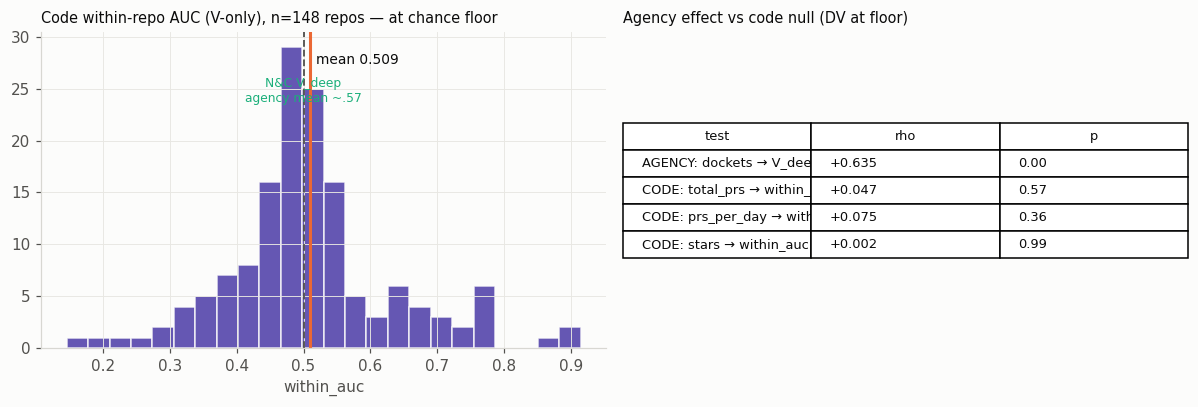

In [130]:
cr = json.loads(Path('../datasets/code-review/pr_test_execution/outputs/org_vat/throughput_vs_within_auc.json').read_text())
rows_cr = next(v for v in cr.values() if isinstance(v, list))
aucs = np.array([r['within_auc'] for r in rows_cr if isinstance(r,dict) and r.get('within_auc') is not None])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.hist(aucs, bins=24, color=PAL['violet'], alpha=.85, edgecolor=SURF)
ax1.axvline(0.5, color=INK2, lw=1.2, ls='--')
ax1.axvline(aucs.mean(), color=PAL['orange'], lw=2)
ax1.text(aucs.mean()+.01, ax1.get_ylim()[1]*.9, f'mean {aucs.mean():.3f}', color=INK, fontsize=9)
ax1.text(.5, ax1.get_ylim()[1]*.78, 'N&C V_deep\nagency mean ~.57', color=PAL['aqua'], fontsize=8, ha='center')
ax1.set_title(f'Code within-repo AUC (V-only), n={len(aucs)} repos — at chance floor', loc='left', fontsize=9.5, color=INK)
ax1.set_xlabel('within_auc')

cc = cr['correlations'] if isinstance(cr.get('correlations'), dict) else {}
# render the code correlation table vs the agency benchmark
comp = pd.DataFrame([
    dict(domain='AGENCY: dockets → V_deep', rho=.635, p=.003, dv_mean=None, note='survives 2 checks'),
    dict(domain='CODE: total_prs → within_auc', rho=.047, p=.57, dv_mean=float(aucs.mean()), note='V-only DV at floor'),
    dict(domain='CODE: prs_per_day → within_auc', rho=.075, p=.36, dv_mean=float(aucs.mean()), note='V-only DV at floor'),
    dict(domain='CODE: stars → within_auc', rho=.002, p=.99, dv_mean=float(aucs.mean()), note=''),
])
ax2.axis('off')
tbl = ax2.table(cellText=[[r.domain, f'{r.rho:+.3f}', f'{r.p:.2f}'] for _,r in comp.iterrows()],
                colLabels=['test','rho','p'], cellLoc='left', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.5)
ax2.set_title('Agency effect vs code null (DV at floor)', loc='left', fontsize=9.5, color=INK)
plt.tight_layout(); plt.show()

## 8. Quoting rules & caveats (binding)

1. **Never quote any-MADE-y** (n_labels confound, .695 mechanical).
2. **Never quote 8B internal-split AUCs** (.89–.93 leaky; honest docket-disjoint = .602/.647).
3. **A row = pre-GEPA bank**; post-GEPA only as the fidelity-vs-prediction tradeoff finding.
4. Per-agency AUCs require ≥20 dockets in-sample; the sub-.35 tail is docket noise.
5. Responded-or-not = "matched-in-pipeline-or-not" (upstream matcher recall unknown).
6. Size/throughput: n=18–19, two confounds controlled, lifetime-total dockets. Suggestive,
   robust to checks run, not yet headline-grade.
7. Agree-y carries a stance component (stance-only .603 vs dense .671) — report both.
8. Docket-year "time" axes are composition-confounded across buckets — descriptive only.

## 9. Agency-level VAT gallery (house style)

All figures below use the paper house style (seaborn "deep" palette: V=blue `#4C72B0`,
V+A=green `#55A868`, C=dense-ceiling red `#C44E52`), matching the math/code VAT plots. y =
**agree-vs-disagree** (the comment-level y). Quantitative-claim figures are restricted to the
**reliable** agencies (≥20 dockets in-sample); the low-docket tail is docket-noise (see §5).

In [131]:
# --- house style shared by the gallery ---
HV, HVA, HC, HGREY = '#4C72B0', '#55A868', '#C44E52', '#888888'
HINK = '#222222'
def house(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4); ax.spines['bottom'].set_color(HINK)
    ax.spines['left'].set_color('#666666'); ax.set_axisbelow(True)

pa = pd.DataFrame(agree_pa).T.astype(float)
dd = pd.DataFrame(divers).set_index('agency')
pa['n_dockets_sample'] = dd['n_dockets_sample']
pa['reliable'] = pa['n_dockets_sample'] >= 20
pa = pa.sort_values('dense', ascending=False)
rel = pa[pa.reliable].copy()
print(f'{len(pa)} agencies, {len(rel)} reliable (>=20 dockets)')

21 agencies, 12 reliable (>=20 dockets)


### 9.1 Per-agency V / V+A / C (reliable agencies, sorted by dense)

The math/code VAT bar plot, drawn per agency. FAA, DOT, CDC show the biggest ceiling (C);
several agencies (CMS, USCIS) have V above their own A/C — the symbolic surface carries more
than the judge there.

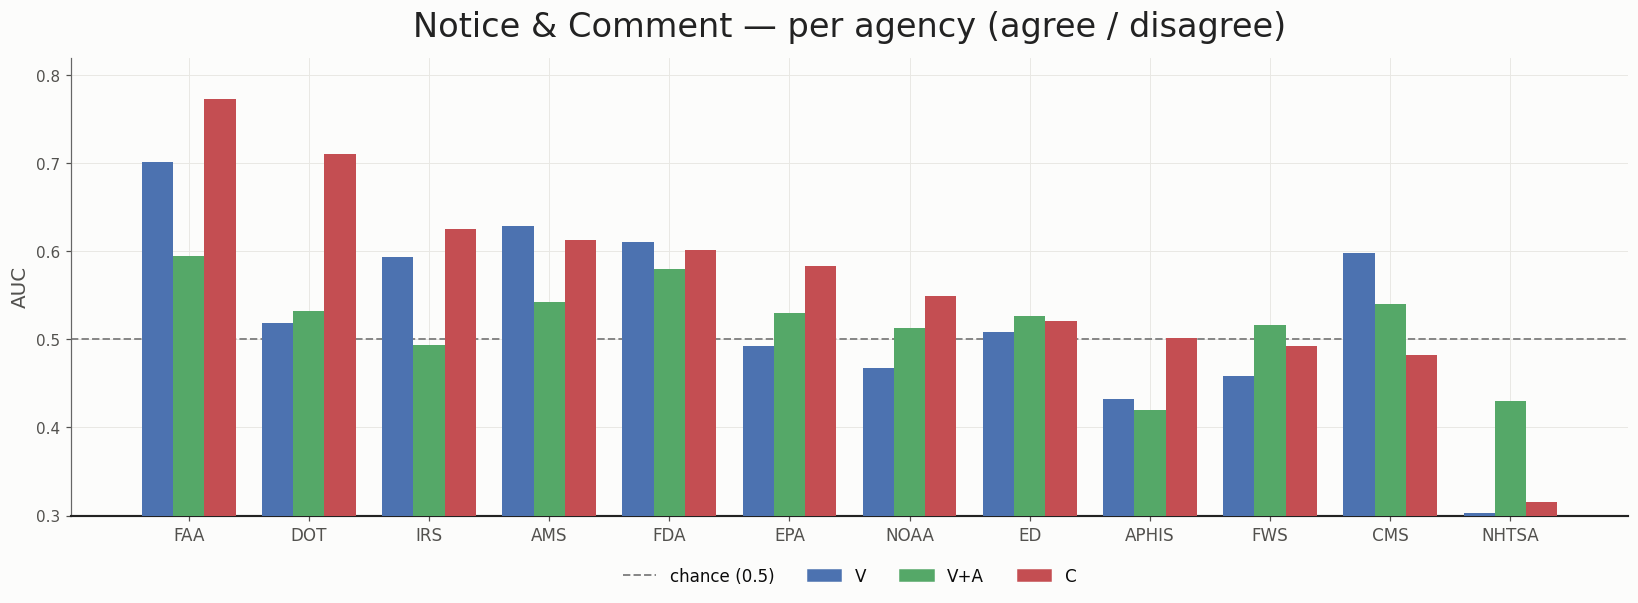

In [132]:
fig, ax = plt.subplots(figsize=(15, 5.6))
g = rel.index.tolist(); x = np.arange(len(g)); w = 0.26
ax.bar(x-w, rel.V,     w, color=HV,  label='V',   zorder=3)
ax.bar(x,   rel.VA,    w, color=HVA, label='V+A', zorder=3)
ax.bar(x+w, rel.dense, w, color=HC,  label='C',   zorder=3)
ax.axhline(0.5, ls='--', color=HGREY, lw=1.3, zorder=1)
ax.set_title('Notice & Comment — per agency (agree / disagree)', fontsize=22, pad=14, color=HINK)
ax.set_ylabel('AUC', fontsize=13); ax.set_ylim(0.30, 0.82)
ax.set_yticks(np.arange(0.30,0.821,0.10))
ax.set_xticks(x); ax.set_xticklabels(g, fontsize=11)
house(ax)
from matplotlib.lines import Line2D; import matplotlib.patches as mpatches
ax.legend(handles=[Line2D([0],[0],ls='--',color=HGREY,lw=1.3,label='chance (0.5)'),
                   mpatches.Patch(color=HV,label='V'), mpatches.Patch(color=HVA,label='V+A'),
                   mpatches.Patch(color=HC,label='C')],
          loc='upper center', bbox_to_anchor=(0.5,-0.08), ncol=4, frameon=False, fontsize=11)
plt.tight_layout(); plt.show()

### 9.1b Three representative docket scales — using V_deep

One comparison for a **high-, medium-, and small-docket agency**, restricted to the reliable set (≥20 sampled dockets). The blue bar is `V_deep` rather than canonical shallow `V`, because docket throughput is associated with `V_deep` (reliable-agency Spearman ρ=.650, p=.022) but not with `V`, `V+A`, or `C`. FAA is the maximum-throughput agency; CMS is the upper member of the two-agency median tie (CMS 760, FWS 740); AMS is the smallest-throughput reliable agency.

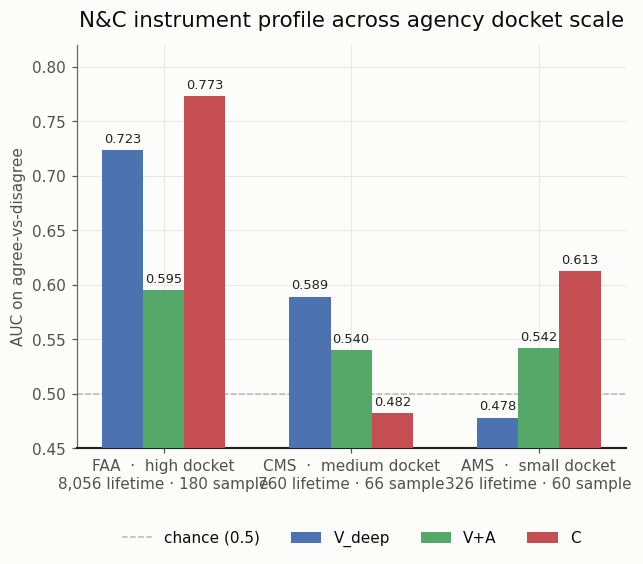

In [142]:
# Representative agencies selected from the reliable per-agency evaluation set.
agency_size = pd.DataFrame(merged).set_index('agency')['dockets']
triad_names = ['FAA', 'CMS', 'AMS']
triad = rel.loc[triad_names].copy()
triad['dockets_lifetime'] = agency_size.loc[triad_names]

x = np.arange(len(triad)); w = .22
fig, ax = plt.subplots(figsize=(6, 5.3))
b_v = ax.bar(x-w, triad.Vdeep, w, color=HV, label='V_deep', zorder=3)
b_va = ax.bar(x, triad.VA, w, color=HVA, label='V+A', zorder=3)
b_c = ax.bar(x+w, triad.dense, w, color=HC, label='C', zorder=3)

ax.axhline(.5, color='#b9b9b9', lw=1, ls='--', zorder=1, label='chance (0.5)')
for bars in (b_v, b_va, b_c):
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8.5, color=HINK)

scale = ['high docket', 'medium docket', 'small docket']
tick_labels = [
    f'{agency}  ·  {tier}\n{int(triad.loc[agency, "dockets_lifetime"]):,} lifetime · '
    f'{int(triad.loc[agency, "n_dockets_sample"])} sample'
    for agency, tier in zip(triad_names, scale)
]
ax.set_xticks(x, tick_labels)
ax.set_ylim(.45, .82)
ax.set_ylabel('AUC on agree-vs-disagree')
ax.set_title('N&C instrument profile across agency docket scale', fontsize=14, pad=12)
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.17))
house(ax)
plt.tight_layout()

**Read:** `V_deep` now supplies the monotone size pattern: FAA `.723` → CMS `.589` → AMS `.478` as docket throughput falls. The other bars do **not** form the same ladder—`V+A` is nearly flat between CMS and AMS, while `C` is non-monotone. That contrast is the result: agency throughput tracks mechanizable substantive signal most clearly, not every component of the canonical VAT profile.

### 9.2 Agency × instrument AUC heatmap

All 21 agencies (unreliable ones marked `*`), every instrument. Diverging around chance (0.5):
red = above chance, blue = below. The sub-.35 blues in the unreliable tail are fold-noise, not
anti-signal.

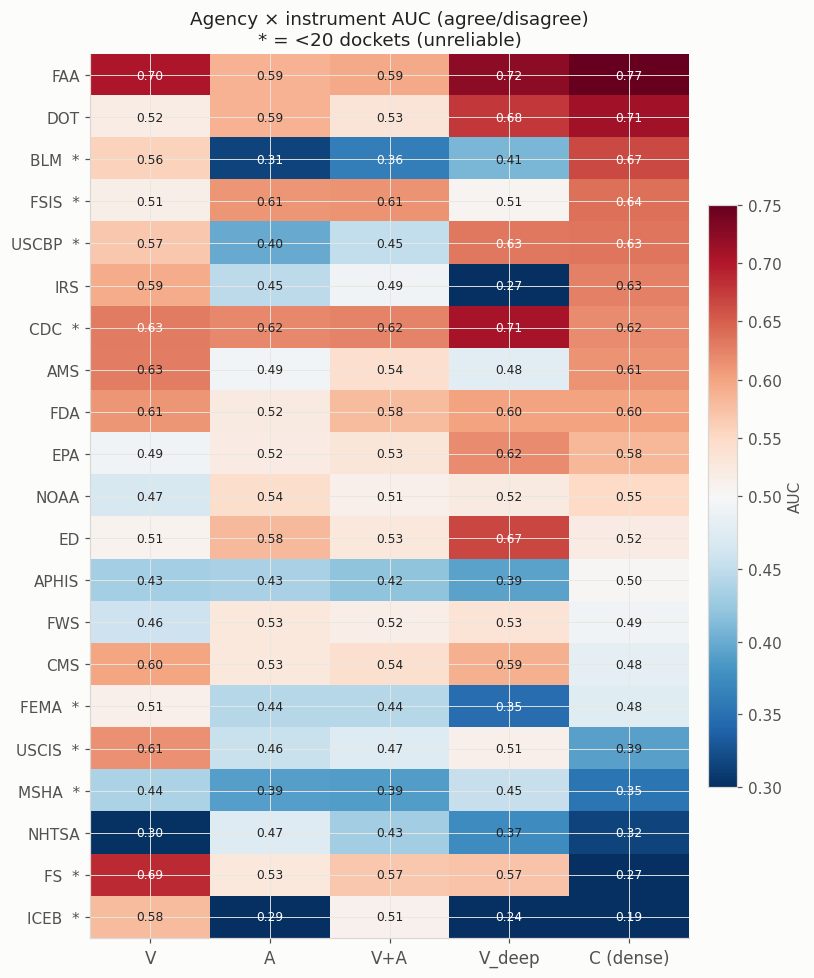

In [134]:
cols = ['V','A','VA','Vdeep','dense']
labels = {'V':'V','A':'A','VA':'V+A','Vdeep':'V_deep','dense':'C (dense)'}
M_ = pa[cols].values.astype(float)
ylab = [f'{a}{"" if pa.loc[a,"reliable"] else "  *"}' for a in pa.index]
fig, ax = plt.subplots(figsize=(7.5, 9))
im = ax.imshow(M_, cmap='RdBu_r', vmin=0.30, vmax=0.75, aspect='auto')
im.set_clim(0.30,0.75)
import matplotlib.colors as mcolors
im.set_norm(mcolors.TwoSlopeNorm(vcenter=0.5, vmin=0.30, vmax=0.75))
ax.set_xticks(range(len(cols))); ax.set_xticklabels([labels[c] for c in cols], fontsize=11)
ax.set_yticks(range(len(ylab))); ax.set_yticklabels(ylab, fontsize=10)
for i in range(M_.shape[0]):
    for j in range(M_.shape[1]):
        v=M_[i,j]; ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8,
                           color='white' if abs(v-0.5)>0.13 else '#222222')
ax.set_title('Agency × instrument AUC (agree/disagree)\n* = <20 dockets (unreliable)', fontsize=12, color=HINK)
cb=plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03); cb.set_label('AUC', fontsize=10)
plt.tight_layout(); plt.show()

### 9.3 Do interpretable programs (V_deep) match the black box (dense)?

Reliable agencies. Points above the diagonal = the 12 hand-written hybrid programs beat a
per-agency TF-IDF model; on the diagonal = they tie. Several agencies (CDC, ED, EPA) sit
clearly above — interpretable instruments win there.

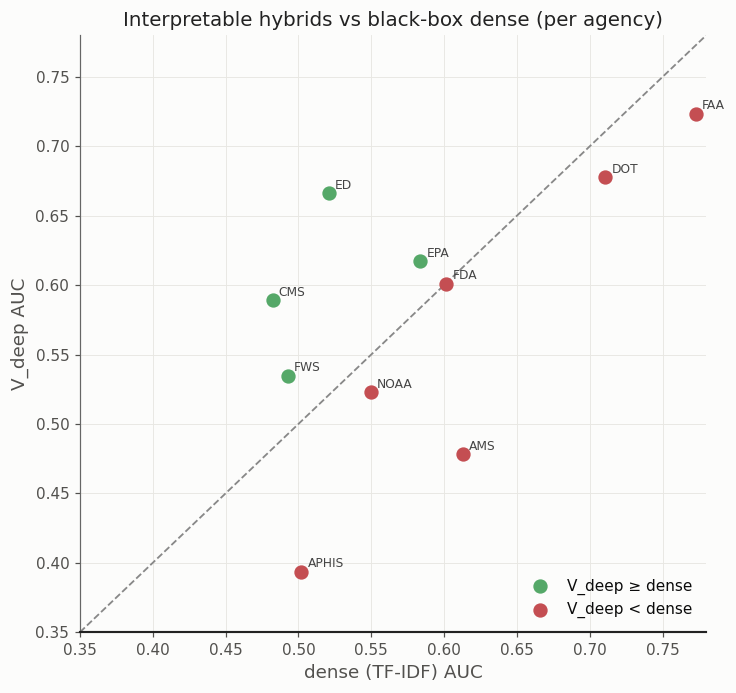

In [135]:
fig, ax = plt.subplots(figsize=(6.8, 6.4))
above = rel.Vdeep >= rel.dense
ax.scatter(rel[above].dense, rel[above].Vdeep, s=70, color=HVA, zorder=3, label='V_deep ≥ dense')
ax.scatter(rel[~above].dense, rel[~above].Vdeep, s=70, color=HC, zorder=3, label='V_deep < dense')
lim=[0.35,0.78]; ax.plot(lim,lim, color=HGREY, ls='--', lw=1.2, zorder=1)
for a,r in rel.iterrows():
    ax.annotate(a, (r.dense, r.Vdeep), textcoords='offset points', xytext=(4,3), fontsize=8, color='#444')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('dense (TF-IDF) AUC', fontsize=12); ax.set_ylabel('V_deep AUC', fontsize=12)
ax.set_title('Interpretable hybrids vs black-box dense (per agency)', fontsize=13, color=HINK)
house(ax); ax.legend(frameon=False, fontsize=10, loc='lower right')
plt.tight_layout(); plt.show()

### 9.4 Per-agency tacit gap: V → C

For each reliable agency, the blue dot is V (symbolic surface) and the red dot is C (dense
ceiling); the bar between them is roughly the per-agency tacit gap. Wide gaps (EPA, ED, FWS)
= lots of accept/reject signal the symbolic features miss; near-zero or reversed (FAA, CMS,
USCIS) = symbolic features already capture it.

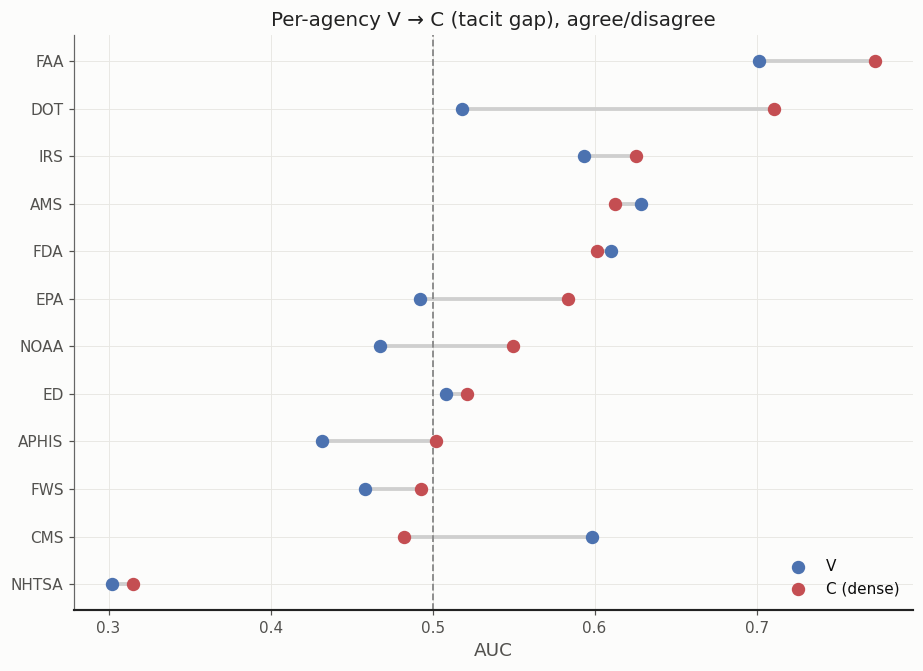

In [136]:
d = rel.sort_values('dense')
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8.5, 6.2))
for yi,(a,r) in zip(y, d.iterrows()):
    ax.plot([r.V, r.dense],[yi,yi], color='#cfcfcf', lw=2.5, zorder=1)
ax.scatter(d.V, y, s=60, color=HV, zorder=3, label='V')
ax.scatter(d.dense, y, s=60, color=HC, zorder=3, label='C (dense)')
ax.axvline(0.5, ls='--', color=HGREY, lw=1.2)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=10)
ax.set_xlabel('AUC', fontsize=12); ax.set_title('Per-agency V → C (tacit gap), agree/disagree', fontsize=13, color=HINK)
house(ax); ax.legend(frameon=False, fontsize=10, loc='lower right')
plt.tight_layout(); plt.show()

### 9.5 Collins RTK: docket throughput → V_deep (house style)

The headline size result, restyled to match. FAA (red) is the high-leverage point; the
correlation survives its removal (ρ=.571) and the sample-diversity partial (ρ=.572) — see §6.

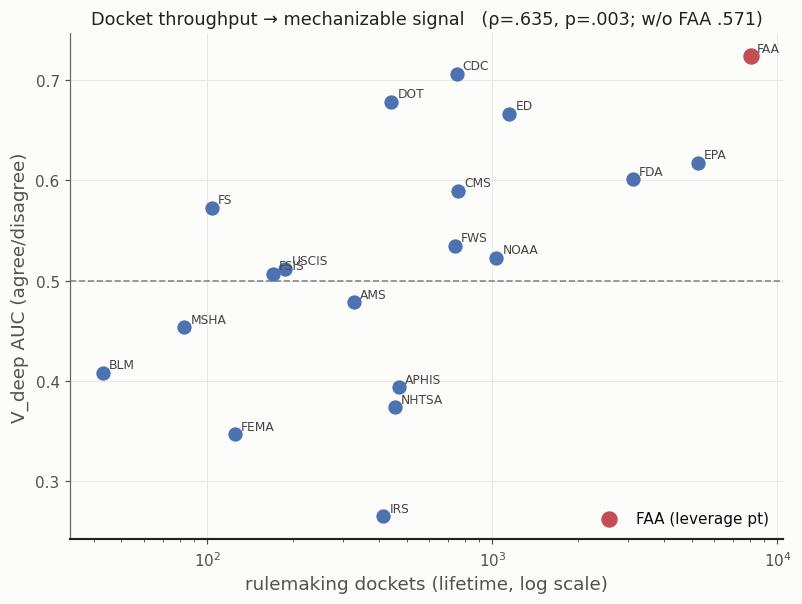

In [137]:
mm = pd.DataFrame(merged).dropna(subset=['dockets','Vdeep'])
faa = mm.agency=='FAA'
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.scatter(mm[~faa].dockets, mm[~faa].Vdeep, s=70, color=HV, zorder=3)
ax.scatter(mm[faa].dockets, mm[faa].Vdeep, s=95, color=HC, zorder=4, label='FAA (leverage pt)')
for _,r in mm.iterrows():
    ax.annotate(r.agency,(r.dockets,r.Vdeep),textcoords='offset points',xytext=(4,3),fontsize=8,color='#444')
# fit line on log-x rank trend (visual only)
ax.set_xscale('log'); ax.axhline(0.5, ls='--', color=HGREY, lw=1.1)
ax.set_xlabel('rulemaking dockets (lifetime, log scale)', fontsize=12)
ax.set_ylabel('V_deep AUC (agree/disagree)', fontsize=12)
ax.set_title('Docket throughput → mechanizable signal   (ρ=.635, p=.003; w/o FAA .571)', fontsize=11.5, color=HINK)
house(ax); ax.legend(frameon=False, fontsize=10, loc='lower right')
plt.tight_layout(); plt.show()

## 10. Org structure → VAT differences

How does agency **structure** translate into per-agency **VAT** differences? §6 / §9.5 show one
slice (docket throughput → V_deep). Here is the full translation in three views:

- **10.1** the structural *landscape* — headcount, throughput, comment intensity, responsiveness,
- **10.2** a structure × VAT scatter *grid* — *which* structure predicts *which* instrument,
- **10.3** a compact Spearman *heatmap* of the whole translation.

**Dissociation to watch:** **FTE headcount tracks only the shallow regex-V (form)**, while
**docket throughput tracks V_deep / dense (substance)** — formality-on-paper vs
formality-in-practice. n=18–21 agencies; descriptive (small n), §6 caveats apply.

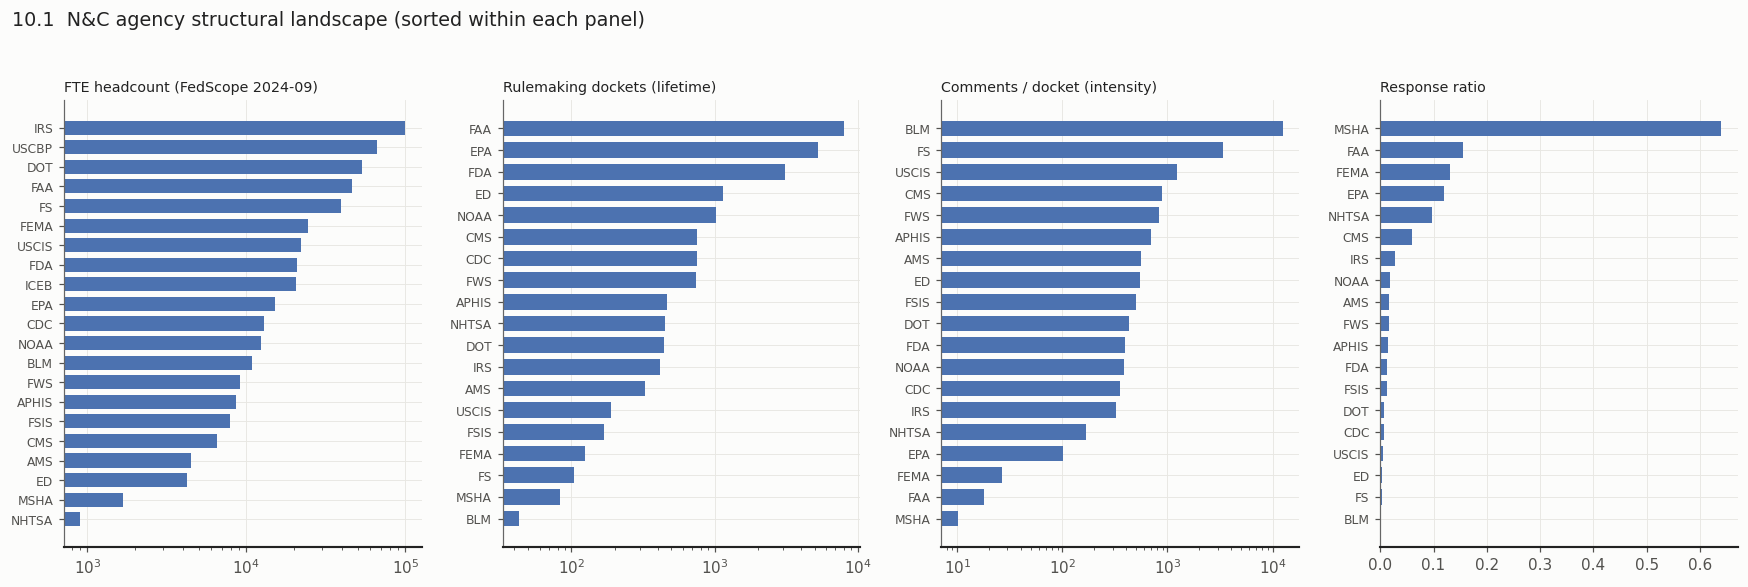

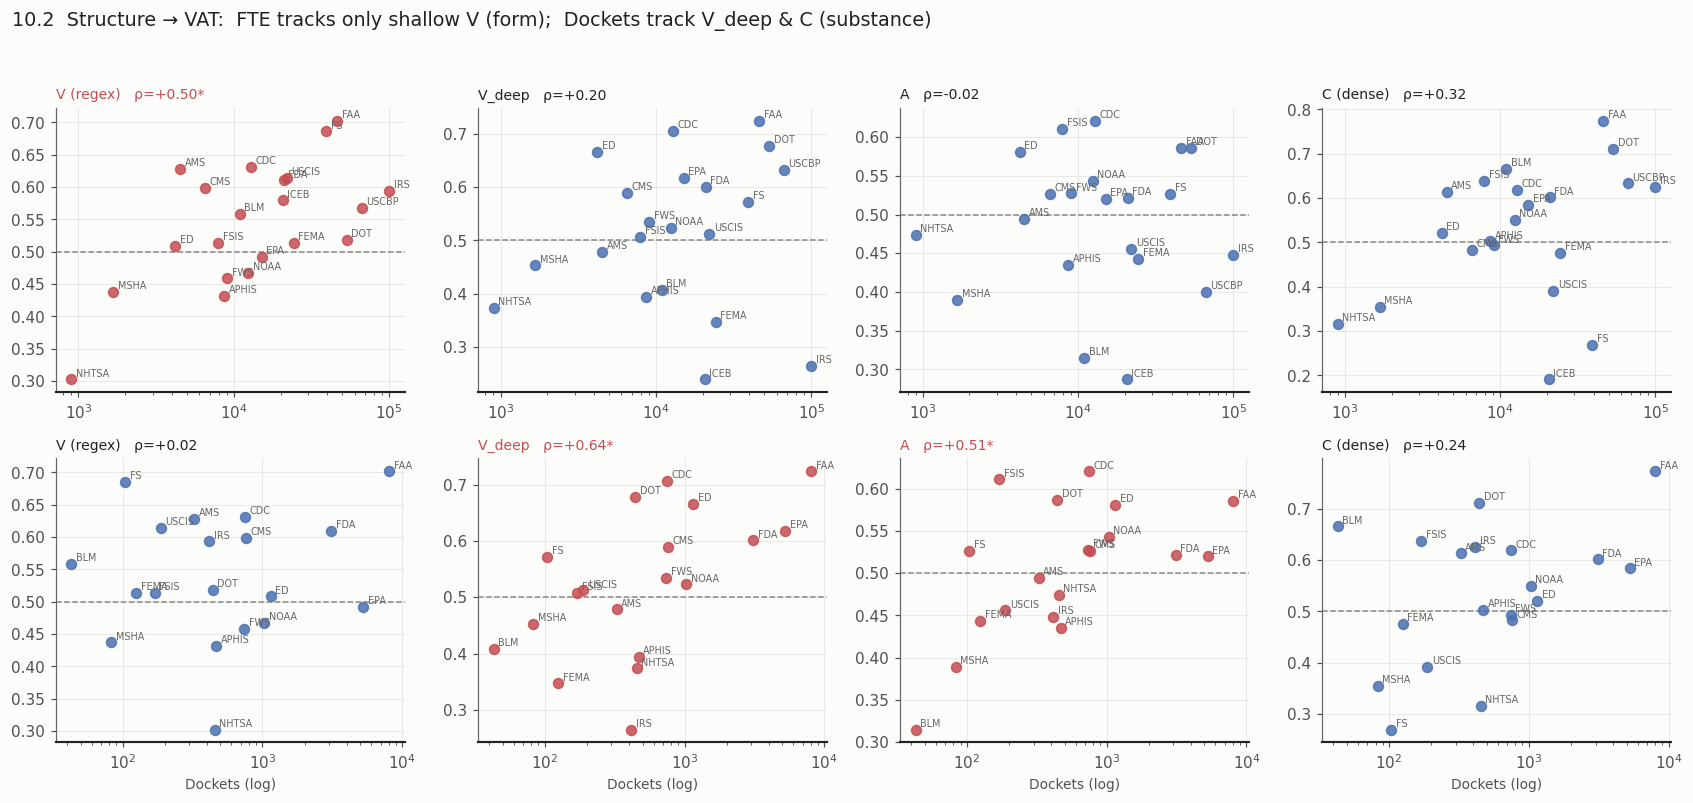

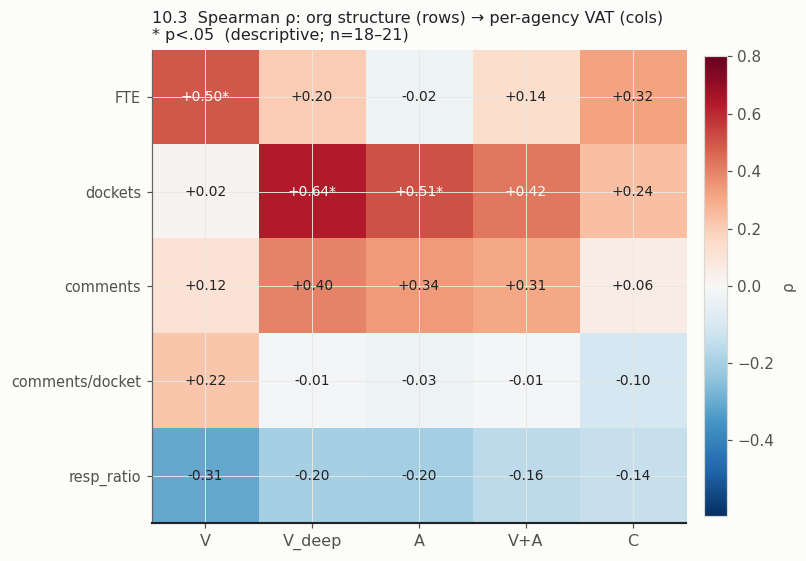

In [138]:
# --- §10  Org structure -> VAT differences  (house style, self-contained) ---
import matplotlib.colors as mc
from scipy.stats import spearmanr
HV, HVA, HC, HGREY, HINK = '#4C72B0', '#55A868', '#C44E52', '#888888', '#222222'
def house(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4); ax.spines['bottom'].set_color(HINK)
    ax.spines['left'].set_color('#666666'); ax.set_axisbelow(True)
mg = pd.DataFrame(merged).set_index('agency')

# ---- 10.1  structural landscape across agencies ----
struct = ['fte','dockets','comments_per_docket','resp_ratio']
titles = {'fte':'FTE headcount (FedScope 2024-09)','dockets':'Rulemaking dockets (lifetime)',
          'comments_per_docket':'Comments / docket (intensity)','resp_ratio':'Response ratio'}
fig, axes = plt.subplots(1, 4, figsize=(16, 5.4))
for ax, c in zip(axes, struct):
    s = mg[c].replace([np.inf, -np.inf], np.nan).dropna().sort_values()
    ax.barh(range(len(s)), s.values, color=HV, height=0.72)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
    if c in ('fte', 'dockets', 'comments_per_docket'):
        ax.set_xscale('log')
    ax.set_title(titles[c], loc='left', fontsize=9.3, color=HINK); house(ax)
fig.suptitle('10.1  N&C agency structural landscape (sorted within each panel)',
             x=0.01, ha='left', fontsize=12.5, color=HINK)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# ---- 10.2  structure x VAT scatter grid (the translation) ----
xvars = [('fte', 'FTE'), ('dockets', 'Dockets')]
yvars = [('V', 'V (regex)'), ('Vdeep', 'V_deep'), ('A', 'A'), ('dense', 'C (dense)')]
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.4))
for i, (xc, xl) in enumerate(xvars):
    for j, (yc, yl) in enumerate(yvars):
        ax = axes[i, j]; s = mg.dropna(subset=[xc, yc])
        rho, p = spearmanr(s[xc], s[yc]); sig = p < 0.05
        ax.scatter(s[xc], s[yc], s=42, color=(HC if sig else HV), alpha=0.85, zorder=3)
        for a, r in s.iterrows():
            ax.annotate(a, (r[xc], r[yc]), textcoords='offset points', xytext=(3, 2), fontsize=6.3, color='#666')
        ax.set_xscale('log'); ax.axhline(0.5, ls='--', color=HGREY, lw=1)
        ax.set_title(f'{yl}   ρ={rho:+.2f}{"*" if sig else ""}', loc='left', fontsize=9.2,
                     color=(HC if sig else HINK))
        if i == 1:
            ax.set_xlabel(xl + ' (log)', fontsize=9)
        house(ax)
fig.suptitle('10.2  Structure → VAT:  FTE tracks only shallow V (form);  Dockets track V_deep & C (substance)',
             x=0.01, ha='left', fontsize=12.5, color=HINK)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# ---- 10.3  Spearman heatmap: structure (rows) -> per-agency VAT (cols) ----
xs  = ['fte', 'dockets', 'comments', 'comments_per_docket', 'resp_ratio']
xlab = ['FTE', 'dockets', 'comments', 'comments/docket', 'resp_ratio']
ys  = ['V', 'Vdeep', 'A', 'VA', 'dense']
ylab = ['V', 'V_deep', 'A', 'V+A', 'C']
R = np.full((len(xs), len(ys)), np.nan); P = np.full_like(R, np.nan)
for i, xc in enumerate(xs):
    for j, yc in enumerate(ys):
        s = mg.dropna(subset=[xc, yc]); rho, p = spearmanr(s[xc], s[yc]); R[i, j] = rho; P[i, j] = p
fig, ax = plt.subplots(figsize=(7.4, 5.2))
im = ax.imshow(R, cmap='RdBu_r', norm=mc.TwoSlopeNorm(vcenter=0, vmin=-0.6, vmax=0.8), aspect='auto')
ax.set_xticks(range(len(ys))); ax.set_xticklabels(ylab, fontsize=10.5)
ax.set_yticks(range(len(xs))); ax.set_yticklabels(xlab, fontsize=9.5)
for i in range(len(xs)):
    for j in range(len(ys)):
        star = '*' if P[i, j] < 0.05 else ''
        ax.text(j, i, f'{R[i, j]:+.2f}{star}', ha='center', va='center', fontsize=9,
                color='white' if abs(R[i, j]) > 0.4 else '#222')
ax.set_title('10.3  Spearman ρ: org structure (rows) → per-agency VAT (cols)\n* p<.05  (descriptive; n=18–21)',
             loc='left', fontsize=10.5, color=HINK)
cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03); cb.set_label('ρ')
house(ax); plt.tight_layout(); plt.show()

### Read
- **Landscape (10.1):** agencies span ~3 orders of magnitude in FTE *and* in dockets; a few (FAA/EPA/FDA) are high-throughput, several (BLM/IRS/FS) are low-docket-but-high-comment-volume.
- **Grid (10.2):** the **FTE row** is flat except on V (regex, ρ=+.50*) — headcount tracks *surface form* only; the **Dockets row** climbs on V_deep (ρ=+.64*) — throughput tracks *verifiable substance*. That is the form-vs-substance dissociation, visible cell by cell.
- **Heatmap (10.3):** the only **significant** warm cell is **dockets × V_deep**. Note `dockets → dense` reads raw +0.24 but is **n.s.** here and **dies under §6's confound checks** (FAA-excluded + sample-diversity partial → ρ≈−.06), whereas **dockets → V_deep survives both** (ρ=.57). FTE's warmth is confined to V; responsiveness (`resp_ratio`) and comment-intensity are near-zero everywhere (flagged noisy in §6) — not mechanizable-structure signals.

**Net:** organizational **size** decorates comments (more citations/structure on the page); organizational **throughput** proceduralizes them into codifiable signal — and the robust part of that is the *deep* verifiable instrument, not the dense black box. Collins RTK, made *procedural* not *headcount-driven* — §6's conclusion, now shown across the full structure × instrument space.

### 10.4 One plot: VAT profile across three docket levels (cleaner trend)

You asked for a trio where the trend reads off the bars. **APHIS → NOAA → FAA** (469 / 1,032 /
8,056 dockets; all reliable, none in the §5 noise tail) is the clean one — **every instrument
climbs monotonically** (V .43→.47→.70, V+A .42→.51→.60, V_deep .39→.52→.72, C .50→.55→.77),
unlike FAA/CMS/AMS (§9.1b) or AMS/FDA/FAA where only V_deep climbed and C was non-monotone.

Honest scope: this trio sits near the docket→V_deep trend line, so it illustrates cleanly —
but it's *illustrative*. Across all 19 agencies the robust, confound-checked correlation is
**V_deep (ρ=.635)**; shallow V and dense have real scatter (§9.5 / 10.2). The trio makes
concrete what "more rulemaking throughput → more mechanizable VAT signal" looks like in one
agency's full profile; it is not itself the evidence (the scatter + ρ is).

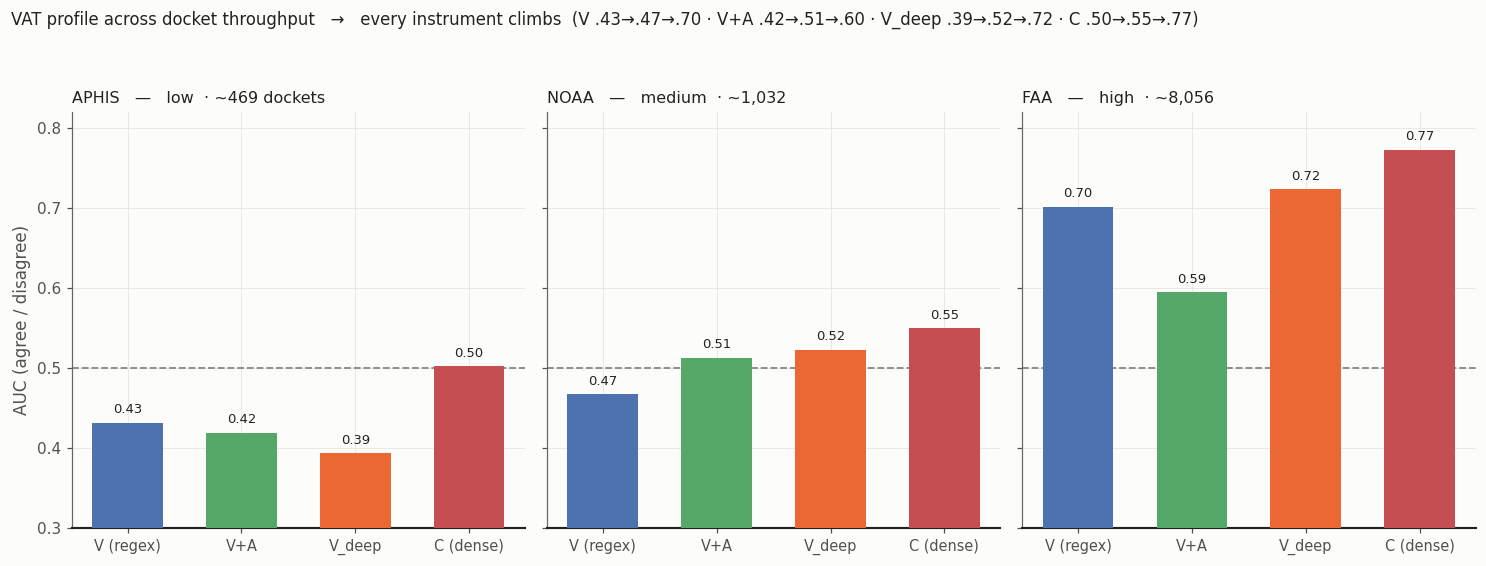

In [139]:
# --- §10.4  ONE plot: VAT profile across three docket levels (clean-trend trio) ---
HV, HVA, HC, HGREY, HINK = '#4C72B0', '#55A868', '#C44E52', '#888888', '#222222'
HVDEEP = '#eb6834'  # V_deep accent (the throughput-tracking instrument)
def house(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4); ax.spines['bottom'].set_color(HINK)
    ax.spines['left'].set_color('#666666'); ax.set_axisbelow(True)
mg = pd.DataFrame(merged).set_index('agency')
# trio chosen to sit near the docket->V_deep trend line so EVERY instrument climbs monotonically
# (unlike FAA/CMS/AMS or AMS/FDA/FAA, where only V_deep climbed)
trio = [('APHIS', 'low  · ~469 dockets'), ('NOAA', 'medium  · ~1,032'), ('FAA', 'high  · ~8,056')]
cols = [('V', HV), ('VA', HVA), ('Vdeep', HVDEEP), ('dense', HC)]
labs = ['V (regex)', 'V+A', 'V_deep', 'C (dense)']
fig, axes = plt.subplots(1, 3, figsize=(13.6, 5.2), sharey=True)
for ax, (ag, lab) in zip(axes, trio):
    r = mg.loc[ag]; x = np.arange(len(cols)); w = 0.62
    ax.bar(x, [r[c] for c, _ in cols], w, color=[cl for _, cl in cols], zorder=3)
    ax.axhline(0.5, ls='--', color=HGREY, lw=1.2)
    ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=9.5)
    for xi, c in enumerate(cols):
        ax.text(xi, r[c[0]] + 0.012, f'{r[c[0]]:.2f}', ha='center', fontsize=8.6, color=HINK)
    ax.set_ylim(0.30, 0.82)
    ax.set_title(f'{ag}   —   {lab}', loc='left', fontsize=10.5, color=HINK)
    house(ax)
axes[0].set_ylabel('AUC (agree / disagree)', fontsize=11)
fig.suptitle('VAT profile across docket throughput   →   every instrument climbs  (V .43→.47→.70 · V+A .42→.51→.60 · V_deep .39→.52→.72 · C .50→.55→.77)',
             x=0.01, ha='left', fontsize=10.8, color=HINK)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

## 10. How the V_deep hybrid metrics work (LLM extract -> program decide)

The metric-seam contract: an LLM (Gemma) extracts a few *typed fields* from the comment, then
a *deterministic program* turns those fields + the raw text into a score in [0,1]
(blend 0.65*code + 0.35*llm). Below, four real traces on real comments from the sample — the
extracted fields, the deterministic decision (with a real intermediate), and the actual
`score()` output. The verification-tier `authority_lookup` is the clearest case: the LLM names
the load-bearing legal authority, and *code checks whether it exists* in a real eCFR index.

In [140]:

import json, importlib.util, pathlib, sys, re, gzip
from IPython.display import HTML, display
BASE = pathlib.Path("../").resolve() if pathlib.Path("../datasets").exists() else pathlib.Path(".").resolve()
REPO = pathlib.Path("/Users/spangher/Projects/stanford-research/norm-research")
HYB = REPO/"methods/metric_seam/hybrids"; PROG = HYB/"programs_notice_and_comment"
for pth in (str(HYB), str(PROG)):
    if pth not in sys.path: sys.path.insert(0, pth)
from ops import Ops

def _load(aid, suf):
    spec = importlib.util.spec_from_file_location(f"nc_{aid}_{suf}", PROG/f"{aid}_{suf}.py")
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m
V4 = REPO/"datasets/notice-and-comment/v4"
MODS = {"citation_validity": _load("citation_validity","h0"), "cba_rigor": _load("cba_rigor","h0"),
        "authority_lookup": _load("authority_lookup","h2"), "stance_alignment": _load("stance_alignment","h1")}
SROWS = {r["doc_id"]: r for r in (json.loads(l) for l in open(V4/"nc_vat_sample.jsonl"))}
SFIELDS = {r["id"]: r["fields"] for r in (json.loads(l) for l in open(V4/"nc_fields_v3.jsonl"))}
_corp = str(V4/"figures/_seam_corp.json")
json.dump([{"datapoint_id": k, "text": v["text"]} for k, v in SROWS.items()], open(_corp,"w"))
OPS = Ops(corpus_path=_corp)
CFR_IDX = json.load(gzip.open(V4/"cfr_parts_index.json.gz","rt"))
import html as _h
def E(s): return _h.escape(str(s))

SEAM_CSS = """
<style>
.seam{--navy:#24364b;--blue:#5875B5;--green:#6FA66F;--red:#B85B5B;--line:#d9dde3;--muted:#67717e;
 font-family:Inter,ui-sans-serif,system-ui,sans-serif;color:#27313d;border:1px solid var(--line);
 border-radius:14px;padding:16px 18px;margin:10px 0;background:linear-gradient(145deg,#fff,#f7f8fa);box-shadow:0 6px 22px #27313d12;}
.seam *{box-sizing:border-box;}
.sm-head{display:flex;justify-content:space-between;align-items:center;gap:12px;margin-bottom:12px;}
.sm-name{font-size:16px;font-weight:800;color:var(--navy);}
.sm-wave{font-size:10.5px;font-weight:700;letter-spacing:.06em;text-transform:uppercase;color:var(--blue);}
.sm-score{font-size:13px;font-weight:800;color:white;background:var(--navy);border-radius:999px;padding:5px 13px;}
.sm-grid{display:grid;grid-template-columns:1fr 22px 1fr 22px 1.1fr;align-items:stretch;}
.sm-col{background:white;border:1px solid var(--line);border-radius:10px;padding:11px 12px;}
.sm-col h5{margin:0 0 6px;font-size:10.5px;letter-spacing:.05em;text-transform:uppercase;}
.sm-col.c1 h5{color:var(--muted);} .sm-col.c2 h5{color:var(--blue);} .sm-col.c3 h5{color:var(--green);}
.sm-arrow{display:grid;place-items:center;color:#9ca4ae;font-size:20px;}
.sm-txt{font-size:11.5px;line-height:1.4;color:#3a4552;}
.sm-field{font-size:11.5px;margin:5px 0;padding:5px 8px;background:#f4f7fc;border-left:3px solid var(--blue);border-radius:5px;}
.sm-field b{color:var(--navy);} .sm-none{color:#a06;font-style:italic;}
.sm-step{font-size:11.5px;margin:4px 0;padding-left:15px;position:relative;}
.sm-step:before{content:"→";position:absolute;left:0;color:var(--green);}
.sm-chip{display:inline-block;font-weight:800;border-radius:999px;padding:1px 8px;font-size:10.5px;}
.sm-yes{background:#e5f2e5;color:#39713f;} .sm-no{background:#f5e7e7;color:#8f4242;}
@media(max-width:900px){.sm-grid{grid-template-columns:1fr;}.sm-arrow{transform:rotate(90deg);height:22px;}}
</style>"""

def seam_card(name, wave, comment, extracted_html, decide_steps, score):
    steps = "".join('<div class="sm-step">%s</div>' % s for s in decide_steps)
    return SEAM_CSS + (
    '<div class="seam"><div class="sm-head"><div><span class="sm-wave">%s &#183; V_deep hybrid</span>'
    '<div class="sm-name">%s</div></div><span class="sm-score">score = %.3f</span></div>'
    '<div class="sm-grid">'
    '<div class="sm-col c1"><h5>1 &#183; comment (real)</h5><div class="sm-txt">%s&#8230;</div></div>'
    '<div class="sm-arrow">&#8594;</div>'
    '<div class="sm-col c2"><h5>2 &#183; LLM extracts (Gemma)</h5>%s</div>'
    '<div class="sm-arrow">&#8594;</div>'
    '<div class="sm-col c3"><h5>3 &#183; program decides (code)</h5>%s</div>'
    '</div></div>') % (wave, name, score, E(comment[:320]), extracted_html, steps)
print("seam helpers ready ; modules:", list(MODS))


seam helpers ready ; modules: ['citation_validity', 'cba_rigor', 'authority_lookup', 'stance_alignment']


In [141]:

def fld(label, val):
    none = (val in (None,"","NONE"))
    cls = "sm-none" if none else ""
    return '<div class="sm-field"><b>%s:</b> <span class="%s">%s</span></div>' % (E(label), cls, E(val if not none else "NONE"))

cards = []

# --- authority_lookup (verification tier): LLM names authority, code checks it EXISTS ---
did = "FWS-HQ-ES-2018-0009-26630"
f = SFIELDS[did].get("authority_lookup", {})
auth = f.get("authority_relied_on","NONE")
m = re.search(r"(\d{1,2})\s*CFR\s*(?:Part\s*)?(\d{1,4})", str(auth), re.I)
title, part = (m.group(1), m.group(2)) if m else (None, None)
exists = bool(title and part and str(part) in set(CFR_IDX.get(str(title), [])))
sc = MODS["authority_lookup"].score(SROWS[did]["text"], f, OPS)
cards.append(seam_card("authority_lookup", "h2", SROWS[did]["text"],
    fld("authority_relied_on", auth),
    ['parse citation &#8594; title=<b>%s</b>, part=<b>%s</b>' % (title, part),
     'look up part in real eCFR index (title %s has %d parts)' % (title, len(CFR_IDX.get(str(title),[]))),
     'authority exists? <span class="sm-chip %s">%s</span>' % ("sm-yes" if exists else "sm-no", "EXISTS" if exists else "NOT FOUND"),
     'load-bearing authority is real &#8594; high score'], sc))

# --- cba_rigor: LLM pulls dollar figures + RIA critique; code magnitude-parses ---
did = "APHIS-2022-0023-0107"
f = SFIELDS[did].get("cba_rigor", {})
figs = f.get("cost_benefit_figures","NONE"); crit = f.get("ria_critique","NONE")
n_dollar = len(re.findall(r"\$\s?[\d,]+(?:\.\d+)?", str(figs)))
sc = MODS["cba_rigor"].score(SROWS[did]["text"], f, OPS)
cards.append(seam_card("cba_rigor", "h0", SROWS[did]["text"],
    fld("cost_benefit_figures", figs) + fld("ria_critique", crit),
    ['magnitude-parse figures &#8594; <b>%d</b> dollar amount(s) detected' % n_dollar,
     'critiques the agency RIA? <span class="sm-chip %s">%s</span>' % (("sm-yes","YES") if crit not in ("NONE","",None) else ("sm-no","NO")),
     'own figures but no RIA engagement &#8594; partial credit'], sc))

# --- citation_validity: mostly-code CFR/USC grammar over the raw text ---
did = "ED-2015-OPE-0103-2477"
f = SFIELDS[did].get("citation_validity", {})
txt = SROWS[did]["text"]
cfr_cites = re.findall(r"\b(\d{1,2})\s*C\.?F\.?R\.?\s*(?:§+\s*)?(\d{1,4})(?:\.(\d{1,4}))?", txt)
valid = [c for c in cfr_cites if 1 <= int(c[0]) <= 50]
sec_level = [c for c in valid if c[2]]
sc = MODS["citation_validity"].score(txt, f, OPS)
cards.append(seam_card("citation_validity", "h0", txt,
    fld("quoted_rule_text", f.get("quoted_rule_text","NONE")),
    ['run CFR grammar over text &#8594; <b>%d</b> CFR citation(s), <b>%d</b> title-valid' % (len(cfr_cites), len(valid)),
     'section-level precision (not just part)? <span class="sm-chip %s">%d</span>' % ("sm-yes" if sec_level else "sm-no", len(sec_level)),
     'quotes specific rule text? <span class="sm-chip %s">%s</span>' % (("sm-yes","YES") if f.get("quoted_rule_text","NONE") not in ("NONE","",None) else ("sm-no","NO")),
     'informal quote, no section-level authority &#8594; mid score'], sc))

# --- stance_alignment: LLM gives one-word position; code grades + parses hedged support ---
did = "FWS-HQ-ES-2018-0007-60746"
f = SFIELDS[did].get("stance_alignment", {})
pos = f.get("overall_position","")
grade = {"support":1.0,"support_with_changes":0.8,"neutral":0.5,"oppose_in_part":0.3,"oppose_fully":0.0}.get(pos)
txt = SROWS[did]["text"]
hedge = bool(re.search(r"support.{0,40}(but|however|except|although)", txt, re.I))
sc = MODS["stance_alignment"].score(txt, f, OPS)
cards.append(seam_card("stance_alignment", "h1", txt,
    fld("overall_position", pos),
    ['map position to alignment grade &#8594; <b>%.2f</b>' % (grade if grade is not None else 0.5),
     'code stance-parser scans support/oppose lexicon + negation',
     'hedged-support ("support&#8230;but") pattern? <span class="sm-chip %s">%s</span>' % (("sm-yes","YES") if hedge else ("sm-no","no")),
     'aligned-with-refinements &#8594; high score'], sc))

for c in cards:
    display(HTML(c))
print("rendered", len(cards), "V_deep seam cards")


rendered 4 V_deep seam cards
